Imports and General Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings('ignore')

import pathlib
import pickle
import copy
import torch
from os import listdir
from os.path import isfile, join
from scipy.stats import sem

# Interactive plots
import PyQt5
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'qt')

# Project modules (pulls in numpy, pandas, mne, sklearn, pyriemann, etc.)
from src.preprocessing import *
from src.training import *
from src.evaluation import *
from src.group_analysis import *

# Define paths
current_path = pathlib.Path().absolute().parent
recording_path = current_path / 'Recordings'
figure_outputs_path = current_path / 'Figures'

# List available recordings
recording_files = [f for f in listdir(recording_path) if isfile(join(recording_path, f)) and '.xdf' in f]
subject_names = [r.split('_')[0] for r in recording_files]
print('Recording files:', recording_files)
print('Subject IDs:', subject_names)

if not figure_outputs_path.exists():
    print('Output folder does not exist:', figure_outputs_path)

# Electrode groups
Electorde_Groups = {
    'FP': ['Fp1', 'Fp2'],
    'AF': ['AF7', 'AF3', 'AFz', 'AF4', 'AF8'],
    'F':  ['F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8'],
    'FC': ['FC5', 'FC3', 'FC1', 'FC2', 'FC4', 'FC6'],
    'C':  ['C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6'],
    'CP': ['CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6'],
    'P':  ['P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8'],
    'PO': ['PO7', 'PO3', 'POz', 'PO4', 'PO8'],
    'O':  ['Oz', 'O2', 'O1', 'Iz']
}

# Group tracking
group_results = []

Recording files: ['DD_1.xdf', 'DD_2.xdf', 'DD_3.xdf', 'DD_Idle.xdf', 'Fudge_MI3_1.xdf', 'Fudge_MI3_2.xdf', 'Fudge_MI3_3.xdf', 'Fudge_MI3_4.xdf', 'GiladRSL1.xdf', 'GiladRSL2.xdf', 'Gilad_3rdArm_0804_1.xdf', 'Gilad_3rdArm_0804_2.xdf', 'Gilad_3rdArm_0804_4.xdf', 'Gilad_3rdArm_0804_5.xdf', 'Gilad_3_AO.xdf', 'Gilad_MI3_1.xdf', 'Gilad_MI3_2.xdf', 'Gilad_MI3_3.xdf', 'Gilad_MI3_4.xdf', 'Gi_Block_1.xdf', 'Gi_Block_3.xdf', 'Gi_Block_4.xdf', 'g_mi_1.xdf', 'g_mi_3.xdf', 'g_mi_4.xdf', 'JE_Idle.xdf', 'JE_MI1.xdf', 'JE_MI2.xdf', 'JE_MI3.xdf', 'JE_MI4.xdf', 'NC_MI1.xdf', 'NC_MI2.xdf', 'NC_MI3.xdf', 'NC_MI4.xdf', 'NH37_Block_1.xdf', 'NH37_Block_2.xdf', 'NH37_Block_3.xdf', 'NH_34_MI5.xdf', 'NH_34_MI6.xdf', 'NH_3_AO.xdf', 'NH_3_MI1.xdf', 'NH_3_MI2.xdf', 'NH_3_MI3.xdf', 'NH_3_MI4.xdf', 'NH_Block_3.xdf', 'NoamV_Idle.xdf', 'NoamV_MI1.xdf', 'NoamV_MI2.xdf', 'NoamV_MI3.xdf', 'NoamV_MI4.xdf', 'Noam_3rdArm_0104_1.xdf', 'Noam_3rdArm_0104_2.xdf', 'Noam_3rdArm_0104_3.xdf', 'Noam_3rdArm_0104_4.xdf', 'Or_MI_1.xdf', 

Define Subject Name

In [173]:
subject_name = 'NC' # Manually define subject name

Choose a parameter dictionary 

In [193]:
params_dict={}
params_dict['PerformCsd']=False
params_dict['PerformAvgRef']=True
Electorde_Group_Names='FC+C+CP+P'
params_dict['Electorde_Group']=[] 
for cur_elec_group_name in Electorde_Group_Names.split('+'):
    params_dict['Electorde_Group']=params_dict['Electorde_Group']+Electorde_Groups[cur_elec_group_name]
params_dict['bad_electrodes'] = get_subject_bad_electrodes (subject_name) # Manually define subject name
params_dict['filter_method']='iir'
params_dict['epoch_tmins_and_maxes_grid'] = [-5,6]
params_dict['epoch_tmin'] = -5
params_dict['epoch_tmax'] = 6
params_dict['n_components']= 4
params_dict['LowPass']=6
params_dict['HighPass']=30
params_dict['filters_bands']=[[7, 12], [12, 20], [20, 28], [28, 35]]
params_dict['augmentation_params']={'win_len': 0, 'win_step': 0.25}
params_dict['classifier_window_s']=0.2
params_dict['classifier_window_e']=4
params_dict['windowed_prediction_params']={'win_len': 2, 'win_step': 0.25}
params_dict['pipeline_name']='csp+lda'
params_dict['n_components_fbcsp']=8
params_dict['desired_events'] = ['ClosePalm','LeftHand','RightHand']


In [ ]:
params_dict={}
params_dict['PerformCsd']=False
params_dict['PerformAvgRef']=True
Electorde_Group_Names='FC+C+CP+P+PO'
params_dict['Electorde_Group']=[] 
for cur_elec_group_name in Electorde_Group_Names.split('+'):
    params_dict['Electorde_Group']=params_dict['Electorde_Group']+Electorde_Groups[cur_elec_group_name]
params_dict['bad_electrodes'] = get_subject_bad_electrodes (subject_name) # Manually define subject name
params_dict['filter_method']='iir'
params_dict['epoch_tmins_and_maxes_grid'] = [-5,6]
params_dict['epoch_tmin'] = -5
params_dict['epoch_tmax'] = 6
params_dict['n_components']= 4
params_dict['LowPass']=6
params_dict['HighPass']=35
params_dict['filters_bands']=[[7, 12], [12, 20], [20, 28], [28, 35]]
params_dict['augmentation_params']={'win_len': 0, 'win_step': 0.25}
params_dict['classifier_window_s']=0.2
params_dict['classifier_window_e']=4
params_dict['windowed_prediction_params']={'win_len': 2, 'win_step': 0.25}
params_dict['pipeline_name']='ts+FGDA'
params_dict['n_components_fbcsp']=8
params_dict['desired_events'] = ['ClosePalm','LeftHand','RightHand']


Load XDF files and convert to combined mne Raw instance

In [194]:
xdf_files = [f for f in recording_path.glob('*.xdf') if subject_name in  f.name] # fill in name to select subject files
#OriginalRaw = Load_and_concatenate_xdf(xdf_files)
xdf_files[:]

[WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/NC_MI1.xdf'),
 WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/NC_MI2.xdf'),
 WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/NC_MI3.xdf'),
 WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/NC_MI4.xdf')]

In [195]:
epochs_list = []
filter_bank_epochs_list = []
movement_events = ['ClosePalm','OpenPalm'] 
for xdf_file in xdf_files[:-1]:
    raw=read_raw_xdf(xdf_file)
    #threshold_raw = filter_events_by_rating(raw,movement_events,rating_threshold = 4)
    #raw_for_ICA = raw_EEG_Preprocessing(current_path,raw,params_dict)
    filtered_raw,epoch,filter_bank_epochs,mean_across_epochs, events_trigger_dict = EEG_Preprocessing(current_path,raw,params_dict, pick_channels=True)
    epoch = remap_epoch_events_to_standard(epoch, standard_event_id, params_dict['desired_events'])
    # Update events_trigger_dict to match new labels
    params_dict['events_trigger_dict'] = {event: standard_event_id[event] for event in params_dict['desired_events']}
    events_trigger_dict = params_dict['events_trigger_dict']
    epochs_list.append(epoch)
    filter_bank_epochs_list.append(filter_bank_epochs)

print("Concatenating all preprocessed epochs...")


epochs = mne.concatenate_epochs(epochs_list, on_mismatch='warn')
filter_bank_epochs = None
epochs

Creating RawArray with float64 data, n_channels=67, n_times=351752
    Range : 0 ... 351751 =      0.000 ...   703.502 secs
Ready.

###########################################################
removing subject specific bad electrodes from the raw data

###########################################################
removing bad channels from epochs:
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.

###########################################################
filtering the data
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 1.00, 100.00 Hz: -3.01, -3.01 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

IIR filter parameters
---------------------
Butterworth bandstop non-linear phase (one-pass fo

Number of events,138
Events,ClosePalm: 46LeftHand: 46RightHand: 46
Time range,-5.000 – 6.000 s
Baseline,off


Balance the classes if required

In [196]:
balanced_epochs = balance_epochs_by_subsampling(epochs, class_to_subsample='Rest')
epochs = balanced_epochs

Pre-processing

In [197]:
events = epochs.events
event_dict = epochs.event_id
params_dict['events_trigger_dict'] = {key: event_dict[key] for key in event_dict.keys() if key in params_dict['desired_events']}
train_inds,validation_inds,return_dict = Split_training_validation (epochs,filter_bank_epochs, params_dict['events_trigger_dict'])
epochs_copy = epochs.copy()
returned_dict=crop_the_data(epochs_copy,train_inds,validation_inds,params_dict['classifier_window_s'],params_dict['classifier_window_e'],use_all_for_training=True) 
train_set_data_uncropped=returned_dict['train_set_data_uncropped']
epochs_cropped=returned_dict['epochs_cropped']
train_set_data=returned_dict['train_set_data']
train_set_labels=returned_dict['train_set_labels']

validation_set_labels=returned_dict['validation_set_labels']
validation_set_data_uncropped=returned_dict['validation_set_data_uncropped']
#define cv on the data: 
cv = StratifiedShuffleSplit(10, test_size=0.2, random_state=random.randrange(1,80))
cv_split = cv.split(epochs_cropped.get_data(),events[:,2])

#filter bank related:
if params_dict['pipeline_name']=='fbcsp+lda': 
    train_set_data_fb=[]
    train_set_data_uncropped_fb=[]
    validation_set_data_fb=[]
    validation_set_data_uncropped_fb=[]
    for filtered_data_band_epoch in preprocessing_dict['filter_bank_epochs']:
        returned_dict_temp=crop_the_data(filtered_data_band_epoch,train_inds,validation_inds, params_dict['classifier_window_s'],params_dict['classifier_window_e'])
        #extract the train set data: 
        train_set_data_uncropped_temp=returned_dict_temp['train_set_data_uncropped']
        train_set_data_temp=returned_dict_temp['train_set_data']
        train_set_data_fb.append(train_set_data_temp)
        train_set_data_uncropped_fb.append(train_set_data_uncropped_temp)
        #extract the validation set data: 
        validation_set_data_uncroped_temp=returned_dict_temp['validation_set_data_uncroped']
        validation_set_data_temp=returned_dict_temp['validation_set_data']
        validation_set_data_fb.append(validation_set_data_temp)
        validation_set_data_uncropped_fb.append(validation_set_data_uncroped_temp)
    #create a 4d matrix of train data:     
    train_set_data_4d_array= np.transpose(np.array(train_set_data_fb),(1,2,3,0))
    train_set_data_uncropped_4d_array=np.transpose(np.array(train_set_data_uncropped_fb),(1,2,3,0)) 
    train_set_data=train_set_data_4d_array
    train_set_data_uncropped=train_set_data_uncropped_4d_array
    #create a 4d matrix of validation data: 
    validation_set_data_4d_array= np.transpose(np.array(validation_set_data_fb),(1,2,3,0))
    validation_set_data_uncropped_4d_array=np.transpose(np.array(validation_set_data_uncropped_fb),(1,2,3,0)) 
    validation_set_data_uncropped=validation_set_data_uncropped_4d_array


augmented_x,augmented_y = augment_data(params_dict['augmentation_params'], train_set_data,train_set_labels,epochs.info['sfreq'])

triggers_label_dict={val:key for key,val in params_dict['events_trigger_dict'].items()} 
test_data_y_labels=np.array([triggers_label_dict[cur_y] for cur_y in validation_set_labels])  
augmented_y_labels=np.array([triggers_label_dict[cur_y] for cur_y in augmented_y])  

putting aside 20% of the data: trial numbers are:
 [ 42 103 115  65  39 101  70  29   0  36 124 108  75 137   1 114  83  99
  72  77  98  68 104 111  13 113 106  64]

remaining 80% of the trials go into training for cv:
 [  4  24  58 125  87  49   9  15  20 100   5  59  19  12  66 135  27 119
  52  81  33 131  89  45 128  23  53 118 130 133 123  91  46 122  96 132
   7  38  82  17 129 107  40  85 121 112  26 126  54  51 134  78   3   8
  37  32  50  71  79  16  57  10  11 120  47   2 117   6  63 105  62  73
  41  69  60  93  56  55  80  74 110  44  35  92  61 102 127  14  95  76
  90  97  86  88 116  48 136  21  34  43  67  31  22  94  84  18  28  30
 109  25]



Cross-Validation Evaluation 

In [198]:
scores_windows, folds_confusion_matrices_per_window, w_times =run_windowed_classification_aug_cv(epochs, returned_dict['epochs_cropped'], cv_split,params_dict)


Computing rank from data with rank=None
    Using tolerance 2.6e-05 (2.2e-16 eps * 28 dim * 4.1e+09  max singular value)
    Estimated rank (mag): 28
    MAG: rank 28 computed from 28 data channels with 0 projectors
Reducing data rank from 28 -> 28
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 2.7e-05 (2.2e-16 eps * 28 dim * 4.3e+09  max singular value)
    Estimated rank (mag): 28
    MAG: rank 28 computed from 28 data channels with 0 projectors
Reducing data rank from 28 -> 28
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 2.5e-05 (2.2e-16 eps * 28 dim * 4.1e+09  max singular value)
    Estimated rank (mag): 28
    MAG: rank 28 computed from 28 data channels with 0 projectors
Reducing data rank from 28 -> 28
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 2.5e-05 (2.2e-16 eps * 28 dim * 4.1e+09  max singular value)
    Estimated rank

In [ ]:
plot_accuracy_over_time(scores_windows, w_times, params_dict, axes_handle=None)
plot_average_confusion_fixed_cv(folds_confusion_matrices_per_window, w_times, t_start=2.0, t_end=5.0)

(array([[0.3902834 , 0.29149798, 0.31821862],
        [0.29032258, 0.49627792, 0.2133995 ],
        [0.2541806 , 0.30602007, 0.43979933]]),
 array(['ClosePalm', 'LeftHand', 'RightHand'], dtype='<U9'))

In [161]:
scores_windows_s1 = scores_windows
folds_cm_s1 = folds_confusion_matrices_per_window
w_times_s1 = w_times

Training

In [162]:
clf,csp,lda = classifier_training(augmented_x,augmented_y,params_dict, BinaryClassification = False)
trained_clf = clf

Computing rank from data with rank=None
    Using tolerance 2e-05 (2.2e-16 eps * 26 dim * 3.5e+09  max singular value)
    Estimated rank (mag): 26
    MAG: rank 26 computed from 26 data channels with 0 projectors
Reducing data rank from 26 -> 26
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 2.1e-05 (2.2e-16 eps * 26 dim * 3.7e+09  max singular value)
    Estimated rank (mag): 26
    MAG: rank 26 computed from 26 data channels with 0 projectors
Reducing data rank from 26 -> 26
Estimating covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 2.2e-05 (2.2e-16 eps * 26 dim * 3.8e+09  max singular value)
    Estimated rank (mag): 26
    MAG: rank 26 computed from 26 data channels with 0 projectors
Reducing data rank from 26 -> 26
Estimating covariance using OAS
Done.


In [163]:
trained_clf

Pipeline(steps=[('csp',
                 CSP({'component_order': 'mutual_info',
 'cov_est': 'concat',
 'cov_method_params': None,
 'log': True,
 'n_components': 6,
 'norm_trace': True,
 'rank': None,
 'reg': 'oas',
 'transform_into': 'average_power'})),
                ('scaler', StandardScaler()),
                ('classifier_LDA', LinearDiscriminantAnalysis())])

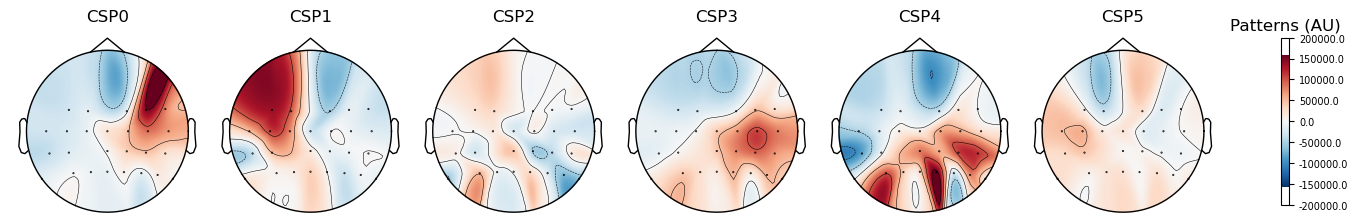

In [164]:
csp.plot_patterns(epochs.info, units='Patterns (AU)', size=1.5)

In [225]:
add_subject_to_group(group_results, subject_name, scores_windows_s1, folds_cm_s1, w_times_s1, 
                     params_dict=params_dict, save_dir=current_path / 'Metrics/Individuals' )

Added Tomer: 10 folds x 37 windows
  Saved metrics to c:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Metrics\Individuals\Tomer_CP_LH_RH_csp+lda.json


[{'subject_name': 'Tomer',
  'timestamp': '2026-02-22T17:13:42.746330',
  'scores_windows': [[0.2857142857142857,
    0.32142857142857145,
    0.2857142857142857,
    0.32142857142857145,
    0.39285714285714285,
    0.42857142857142855,
    0.4642857142857143,
    0.39285714285714285,
    0.42857142857142855,
    0.42857142857142855,
    0.35714285714285715,
    0.32142857142857145,
    0.2857142857142857,
    0.21428571428571427,
    0.14285714285714285,
    0.21428571428571427,
    0.25,
    0.4642857142857143,
    0.5,
    0.6428571428571429,
    0.7142857142857143,
    0.8214285714285714,
    0.7857142857142857,
    0.7857142857142857,
    0.7857142857142857,
    0.8571428571428571,
    0.8214285714285714,
    0.7857142857142857,
    0.75,
    0.75,
    0.75,
    0.75,
    0.6071428571428571,
    0.5714285714285714,
    0.5357142857142857,
    0.42857142857142855,
    0.39285714285714285],
   [0.35714285714285715,
    0.35714285714285715,
    0.39285714285714285,
    0.46428571428

In [114]:

# After all subjects are processed:
print(f"Group results collected for {len(group_results)} subjects:")
for entry in group_results:
    print(f"  - {entry['subject_name']}: {len(entry['scores_windows'])} folds")

# Save group results to disk (note: confusion matrices are NOT saved, only metadata)
save_group_results(group_results, current_path / 'Metrics/Group')

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results,n_classes=4, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, w_times,t_start=2, t_end=5, normalize=True)

print("✓ Group analysis complete!")


Group results collected for 6 subjects:
  - Tomer: 10 folds
  - NC: 10 folds
  - NoamV: 10 folds
  - DD: 10 folds
  - JE: 10 folds
  - GiladRSL: 10 folds
Saved 6 subjects to c:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Metrics\Group\group_Tomer_NC_NoamV_DD_JE_GiladRSL_CP_LH_RH_R_csp+lda.json
✓ Group analysis complete!


In [106]:
import json

file_path = 'group_results_3_classes.json'

with open(file_path, 'r') as f:
    group_results = json.load(f)

print(f"Loaded data for {len(group_results)} subjects.")

Loaded data for 6 subjects.


In [414]:

# Plotting group results
# Plot 1: Group mean accuracy over time
plot_accuracy_over_time_group(group_results,n_classes = 3, figsize=(12, 5))

# Plot 2: Group average confusion matrix (all windows, all subjects)
#plot_average_confusion_fixed_cv_group(group_results, window_index=None, normalize=True)

# Or focus on specific time windows (e.g., windows 20-33)
plot_average_confusion_fixed_cv_group(group_results, window_index=range(20, 33), normalize=True)

print("✓ Group analysis complete!")

✓ Group analysis complete!


In [ ]:
len(folds_confusion_matrices_per_window[0])

49

Sanity check on unhandled recording: 

In [165]:

xdf_files[-1:]


[WindowsPath('c:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Recordings/Tomer_RSL4.xdf')]

In [166]:
epochs_list = []
filter_bank_epochs_list = []
movement_events = ['ClosePalm','OpenPalm'] 
for xdf_file in xdf_files[-1:]:
    raw=read_raw_xdf(xdf_file)
    #threshold_raw = filter_events_by_rating(raw,movement_events,rating_threshold = 4)
    _,epoch,filter_bank_epochs,mean_across_epochs, events_trigger_dict = EEG_Preprocessing(current_path,raw,params_dict)
    epoch = remap_epoch_events_to_standard(epoch, standard_event_id, params_dict['desired_events'])
    # Update events_trigger_dict to match new labels
    params_dict['events_trigger_dict'] = {event: standard_event_id[event] for event in params_dict['desired_events']}
    events_trigger_dict = params_dict['events_trigger_dict']
    epochs_list.append(epoch)
    filter_bank_epochs_list.append(filter_bank_epochs)

print("Concatenating all preprocessed epochs...")


epochs = mne.concatenate_epochs(epochs_list, on_mismatch='warn')
filter_bank_epochs = None

Creating RawArray with float64 data, n_channels=67, n_times=252012
    Range : 0 ... 252011 =      0.000 ...   504.022 secs
Ready.

###########################################################
removing subject specific bad electrodes from the raw data

###########################################################
removing bad channels from epochs:
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.

###########################################################
filtering the data
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass non-linear phase (one-pass forward) causal filter:
- Filter order 8 (forward)
- Cutoffs at 1.00, 100.00 Hz: -3.01, -3.01 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

IIR filter parameters
---------------------
Butterworth bandstop non-linear phase (one-pass fo

In [167]:
Raw_for_analysis = mne.preprocessing.compute_current_source_density(raw) ## Compute CSD
Raw_for_analysis = Raw_for_analysis.filter(8, 35, method='fir')
original_ann = Raw_for_analysis.annotations
event_ann = expand_triggers_to_events(original_ann,Raw_for_analysis)
Raw_for_analysis.set_annotations(event_ann)

Fitted sphere radius:         95.0 mm
Origin head coordinates:      0.0 -0.0 0.0 mm
Origin device coordinates:    0.0 -0.0 0.0 mm
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 825 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  58 out of  58 | elapsed:    0.3s finished


Measurement date,Unknown
Experimenter,Unknown
Participant,Unknown
Digitized points,68 points
Good channels,58 Current source density
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,500.00 Hz
Highpass,8.00 Hz
Lowpass,35.00 Hz


In [168]:
epochs

Number of events,40
Events,ClosePalm: 13LeftHand: 13RightHand: 14
Time range,-5.000 – 6.000 s
Baseline,off


In [169]:
trained_clf=clf
#data_to_predict=(data_set_fb_4d_array[inds,:])
data_to_predict=epochs[:].copy().crop(tmin=1,tmax=3
                                      ).get_data()
thresholded_prediction=trained_clf.decision_function(data_to_predict)
prediction=trained_clf.predict(data_to_predict)

#note that here you can decide on which thresholds to use to better optimize your "real" usecase
#thresholded_prediction
yhat=trained_clf.predict(data_to_predict)
lr_probs = trained_clf.predict_proba(data_to_predict)

In [ ]:
# %%


# Function to get the list of event names for each epoch
# Function to compare actual event names with predicted event names and summarize mismatches
# Example usage:
# Assume `epochs` is your mne.Epochs object, and `predictions` is the model output

actual_events = get_epoch_events(epochs[:])  # Actual events from the epochs
predicted_events = np.array(prediction)  # Replace with your model predictions

# Compare actual events to predicted events
result = compare_events(actual_events, predicted_events)

# Output the comparison result
print(f"Accuracy: {result['accuracy']:.2f}")
if result['mismatch_details']:
    print("Mismatched epochs:")
    for mismatch in result['mismatch_details']:
        print(mismatch)
    
    print("\nMismatch Summary:")
    for mismatch_case, count in result['mismatch_counts'].items():
        print(f"{mismatch_case}: {count} occurrence(s)")
else:
    print("No mismatches!")

Accuracy: 0.85
Mismatched epochs:
2 - ClosePalm (actual), LeftHand (predicted)
17 - RightHand (actual), LeftHand (predicted)
27 - RightHand (actual), LeftHand (predicted)
28 - RightHand (actual), LeftHand (predicted)
30 - RightHand (actual), LeftHand (predicted)
37 - ClosePalm (actual), LeftHand (predicted)

Mismatch Summary:
ClosePalm -> LeftHand: 2 occurrence(s)
RightHand -> LeftHand: 4 occurrence(s)


In [171]:
# Function to compare events excluding Rest
# Example usage:
result_without_rest = compare_events_without_rest(actual_events, predicted_events)

# Output the comparison result
print(f"\n{'='*50}")
print(f"ACCURACY WITHOUT REST")
print(f"{'='*50}")
print(f"Accuracy (excluding Rest): {result_without_rest['accuracy']:.2f}")
print(f"Total non-Rest epochs evaluated: {result_without_rest['total_non_rest_epochs']}")

if result_without_rest['mismatch_details']:
    print("\nMismatched epochs (non-Rest only):")
    for mismatch in result_without_rest['mismatch_details'][:10]:  # Show first 10
        print(mismatch)
    if len(result_without_rest['mismatch_details']) > 10:
        print(f"... and {len(result_without_rest['mismatch_details']) - 10} more")
    
    print("\nMismatch Summary (non-Rest only):")
    for mismatch_case, count in result_without_rest['mismatch_counts'].items():
        print(f"{mismatch_case}: {count} occurrence(s)")
else:
    print("No mismatches on non-Rest epochs!")


ACCURACY WITHOUT REST
Accuracy (excluding Rest): 0.85
Total non-Rest epochs evaluated: 40

Mismatched epochs (non-Rest only):
2 - ClosePalm (actual), LeftHand (predicted)
17 - RightHand (actual), LeftHand (predicted)
27 - RightHand (actual), LeftHand (predicted)
28 - RightHand (actual), LeftHand (predicted)
30 - RightHand (actual), LeftHand (predicted)
37 - ClosePalm (actual), LeftHand (predicted)

Mismatch Summary (non-Rest only):
ClosePalm -> LeftHand: 2 occurrence(s)
RightHand -> LeftHand: 4 occurrence(s)


In [172]:
# Sanity check - windowed evaluation on trained classifier
scores_windows, confusion_matrices_per_window, w_times = sanity_check_trained_clf(
    trained_clf, epochs, params_dict
)

# Accuracy over time
plot_accuracy_over_time(scores_windows, w_times, params_dict)

# Average confusion matrix between time points

plot_average_confusion_fixed_cv(confusion_matrices_per_window, w_times, t_start=2, t_end=5)

(array([[0.81656805, 0.13609467, 0.04733728],
        [0.05325444, 0.91715976, 0.0295858 ],
        [0.        , 0.23076923, 0.76923077]]),
 array(['ClosePalm', 'LeftHand', 'RightHand'], dtype='<U9'))

In [20]:
# Predict on cropped epochs
data_to_predict = epochs[:].copy().crop(tmin=1, tmax=3).get_data()
lr_probs = trained_clf.predict_proba(data_to_predict)
prediction = trained_clf.predict(data_to_predict)
actual_events = get_epoch_events(epochs[:])
class_names = trained_clf.classes_

# --- Probability heatmap per trial, sorted by true class ---
sort_idx = np.argsort(actual_events)
probs_sorted = lr_probs[sort_idx]
actual_sorted = actual_events[sort_idx]

fig, ax = plt.subplots(figsize=(6, max(4, len(actual_sorted) * 0.18)))
im = ax.imshow(probs_sorted, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_yticks(range(len(actual_sorted)))
ax.set_yticklabels([f"{i+1} ({actual_sorted[i]})" for i in range(len(actual_sorted))], fontsize=7)
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_xlabel('Predicted Class Probability')
ax.set_ylabel('Trial (sorted by true class)')
ax.set_title('Per-Trial Prediction Probabilities')
fig.colorbar(im, ax=ax, label='Probability')
plt.tight_layout()


In [95]:
# --- Mean probability matrix: true class vs predicted probability ---
unique_classes = list(class_names)
mean_prob_matrix = np.zeros((len(unique_classes), len(unique_classes)))
for i, true_class in enumerate(unique_classes):
    mask = actual_events == true_class
    if mask.sum() > 0:
        mean_prob_matrix[i] = lr_probs[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mean_prob_matrix, cmap='RdYlGn', vmin=0, vmax=1)
for i in range(len(unique_classes)):
    for j in range(len(unique_classes)):
        ax.text(j, i, f'{mean_prob_matrix[i, j]:.2f}', ha='center', va='center',
                color='black' if mean_prob_matrix[i, j] > 0.3 else 'white', fontsize=11)
ax.set_xticks(range(len(unique_classes)))
ax.set_xticklabels(unique_classes, rotation=45, ha='right')
ax.set_yticks(range(len(unique_classes)))
ax.set_yticklabels(unique_classes)
ax.set_xlabel('Predicted Class (mean probability)')
ax.set_ylabel('True Class')
ax.set_title('Mean Prediction Probability by True Class')
fig.colorbar(im, ax=ax, label='Mean Probability')
plt.tight_layout()

# --- Per-trial summary table ---
rows = []
for i in range(len(actual_events)):
    row = {'Trial': i+1, 'True': actual_events[i], 'Predicted': prediction[i]}
    for j, cls in enumerate(class_names):
        row[f'P({cls})'] = f'{lr_probs[i, j]:.3f}'
    row['Correct'] = actual_events[i] == prediction[i]
    rows.append(row)
df = pd.DataFrame(rows)
print(f"Overall accuracy: {np.mean(actual_events == prediction):.2f}")
print(f"Mean max confidence: {lr_probs.max(axis=1).mean():.3f}")
df


Overall accuracy: 0.80
Mean max confidence: 0.838


,Trial,True,Predicted,P(ClosePalm),P(LeftHand),P(RightHand),Correct
0,1,ClosePalm,ClosePalm,0.988,0.011,0.000,True
1,2,LeftHand,LeftHand,0.190,0.475,0.335,True
2,3,LeftHand,ClosePalm,0.595,0.169,0.237,False
3,4,LeftHand,ClosePalm,0.985,0.015,0.000,False
4,5,LeftHand,RightHand,0.005,0.057,0.937,False
5,6,LeftHand,LeftHand,0.332,0.341,0.327,True
6,7,LeftHand,ClosePalm,0.833,0.099,0.068,False
7,8,RightHand,RightHand,0.000,0.006,0.994,True
8,9,ClosePalm,ClosePalm,0.999,0.001,0.000,True
9,10,RightHand,RightHand,0.008,0.011,0.980,True


In [21]:
# Pick the time window with best accuracy
best_idx = np.argmax(scores_windows[0])
cm, classes = confusion_matrices_per_window[0][best_idx]
plot_confusion_matrix(cm, classes, title=f"Confusion Matrix at t={w_times[best_idx]:.2f}s")

In [26]:
cm_avg, classes = plot_avg_confusion_matrix(
    confusion_matrices_per_window, w_times, 
    t_start=0, t_end=4.0
)

## Co-Adaptive Learning
After each new block, accumulate epochs and retrain the classifier with exponential block weights — giving more influence to recent data.

**Workflow:**
1. After Block 1: run standard training (cells above) → `trained_clf`
2. After each subsequent block: load new epochs, run the cell below to retrain

In [ ]:
# --- Initialise on first run (after Block 1) ---
# Stores epochs and trial counts per block for weighted retraining
if 'adaptive_block_epochs' not in dir():
    adaptive_block_epochs = [epochs.copy()]   # seed with Block 1 epochs
    print(f"Adaptive learning initialised with Block 1 ({len(epochs)} trials).")

In [ ]:
# --- Run this cell after each new block is recorded ---

# 1. Load the new block's XDF and preprocess
new_xdf_files = [f for f in recording_path.glob('*.xdf') if subject_name in f.name]
# TODO: update the slice below to select only the new block file(s)
new_xdf = new_xdf_files[-1:]   # <-- adjust as needed
print(f"Loading new block: {[f.name for f in new_xdf]}")

new_epochs_list = []
for xdf_file in new_xdf:
    raw = read_raw_xdf(xdf_file)
    _, epoch, _, _, _ = EEG_Preprocessing(current_path, raw, params_dict, pick_channels=True)
    epoch = remap_epoch_events_to_standard(epoch, standard_event_id, params_dict['desired_events'])
    params_dict['events_trigger_dict'] = {event: standard_event_id[event] for event in params_dict['desired_events']}
    new_epochs_list.append(epoch)

new_block_epochs = mne.concatenate_epochs(new_epochs_list, on_mismatch='warn')
adaptive_block_epochs.append(new_block_epochs)
print(f"Total blocks accumulated: {len(adaptive_block_epochs)}")

In [ ]:
# --- Weighted retrain ---
alpha = 0.7   # decay factor: reduce to weight recent blocks more aggressively

# Combine all blocks and compute per-trial weights
all_epochs = mne.concatenate_epochs(adaptive_block_epochs, on_mismatch='warn')
block_counts = [len(e) for e in adaptive_block_epochs]
sample_weight = compute_block_weights(block_counts, alpha=alpha)

print(f"Block sizes: {block_counts}")
print(f"Block weights (normalised): {[round(sample_weight[sum(block_counts[:i])], 3) for i in range(len(block_counts))]}")

# Crop to classifier window and augment
epochs_copy = all_epochs.copy()
returned_dict_adaptive = crop_the_data(
    epochs_copy, np.arange(len(all_epochs)), [],
    params_dict['classifier_window_s'], params_dict['classifier_window_e'],
    use_all_for_training=True
)
train_x = returned_dict_adaptive['train_set_data']
train_y = returned_dict_adaptive['train_set_labels']

# Augment
aug_x, aug_y = augment_data(params_dict['augmentation_params'], train_x, train_y, all_epochs.info['sfreq'])

# Expand weights to match augmented dataset, then resample
aug_factor = len(aug_x) // len(train_x)
remainder  = len(aug_x) %  len(train_x)
aug_weights = np.concatenate([np.tile(sample_weight, aug_factor),
                               sample_weight[:remainder]])

# Resample data proportional to weights (works with any estimator)
aug_x_resampled, aug_y_resampled = resample_by_weights(aug_x, aug_y, aug_weights)
print(f"Resampled dataset: {len(aug_y_resampled)} trials (from {len(aug_y)} augmented)")

# Retrain
trained_clf, csp, lda = classifier_training(aug_x_resampled, aug_y_resampled, params_dict)
print(f"Classifier retrained on {len(all_epochs)} trials across {len(adaptive_block_epochs)} blocks.")

In [ ]:
# --- Quick sanity check on the updated classifier ---
scores_windows, confusion_matrices_per_window, w_times = sanity_check_trained_clf(
    trained_clf, all_epochs, params_dict
)
plot_accuracy_over_time(scores_windows, w_times, params_dict)
plot_average_confusion_fixed_cv(confusion_matrices_per_window, w_times, t_start=2, t_end=5)

Save the trained model 


In [673]:
fname = 'DD_Raw_for_analysis_180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(Raw_for_analysis, picklefile)
#close the file
picklefile.close()

# === Saving ===
ann_fname = current_path / 'Models' / 'DD_ann_180226'
with open(ann_fname, 'wb') as f:
    pickle.dump(event_ann, f)
# === Saving ===
with open(ann_fname, 'wb') as f:
    pickle.dump(event_ann, f)



In [176]:
picks=params_dict['Electorde_Group']


import joblib
# === Saving ===
channels_fname = current_path / 'Models' / 'channels_list_180226.pkl'
model_fname = current_path / 'Models' / 'ts_model_180226.joblib'
with open(channels_fname, 'wb') as f:
    pickle.dump(picks, f)

joblib.dump(clf, model_fname)


# %%

Saved_Model = trained_clf
fname = 'DD_3rd_arm'+'Rest_ts_model_180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(Saved_Model, picklefile)
#close the file
picklefile.close()



picks=params_dict['Electorde_Group']
fname = 'electrode_picks-180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(picks, picklefile)
#close the file
picklefile.close()


fname = 'mean'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(mean_across_epochs, picklefile)
#close the file
picklefile.close()

params_dict
fname = 'params_dict-Rest_DD_180226'
path_fname = current_path /'Models'/ fname

#create a pickle file
picklefile = open(path_fname, 'wb')
#pickle the dictionary and write it to file
pickle.dump(params_dict, picklefile)
#close the file
picklefile.close()

In [ ]:

scaler = RobustScaler()
all_epoch_data_flat = all_epoch_data.reshape(all_epoch_data.shape[0], -1)
all_epoch_data_normalized = scaler.fit_transform(all_epoch_data_flat).reshape(all_epoch_data.shape)

# Update combined epochs with normalized data
epochs._data = all_epoch_data_normalized

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler
